# Numerical Methods in Cosmology

This notebook implements some simple finite difference examples in python. The corresponding notes are available at: ...

First, we load some standard python modules for array manipulations (numpy) and plotting (matplotlib). This may take a while as the kernel loads for the first time.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In these examples, we will always work on the domain $D = [0,2\pi]$. We begin by creating a discrete uniform grid containing $N$ points.

In [ ]:
N = 25 # Number of grid points
Ngz = 2 # Number of ghost points
x_min = 0.0 # Start of domain
x_max = 2*np.pi # End of domain
dx = (x_max - x_min)/(N-1) # The spatial step size

grid = np.zeros(N+2*Ngz) # Initialise array for the computational grid

for i in range(N + 2*Ngz):
  grid[i] = x_min + (i - Ngz)*dx

print(grid)

[-0.52359878 -0.26179939  0.          0.26179939  0.52359878  0.78539816
  1.04719755  1.30899694  1.57079633  1.83259571  2.0943951   2.35619449
  2.61799388  2.87979327  3.14159265  3.40339204  3.66519143  3.92699082
  4.1887902   4.45058959  4.71238898  4.97418837  5.23598776  5.49778714
  5.75958653  6.02138592  6.28318531  6.54498469  6.80678408]


Let's plot the function $\sin(x)$ on this domain. Note that the first and last two points of the domain are "ghost" points and not part of the physical domain.


Try changing the value of $N$ in the above cell to see how the plot changes.

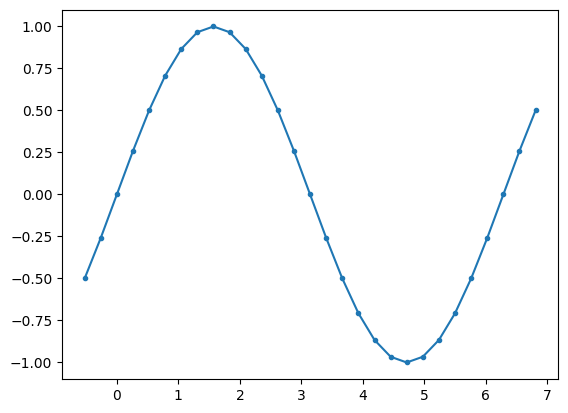

In [ ]:
plt.plot(grid,np.sin(grid),'.-')
plt.show()

Now, we want to approximate the first derivative of $\sin(x)$ using finite differences.

Let's define a function to compute the second order central finite difference.

In [ ]:
def FD_C2(u,dx):

  du = np.zeros_like(u) # Initialise an array for the derivatives

  du[2:-2] = (u[3:-1] - u[1:-3])/(2*dx) # Observe we only fill the physical grid values!

  return du

Now, let's compute the derivative of $\sin(x)$ using the finite difference function. Then, we can compare our approximation to the exact solution $\cos(x)$.

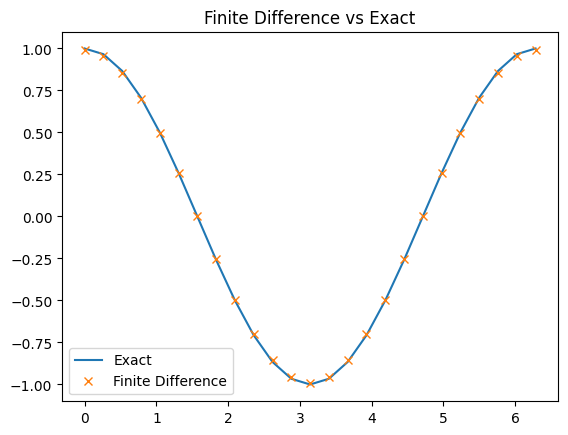

In [ ]:
u = np.sin(grid) # Define the function to differentiate
du = FD_C2(u,dx) # Compute the derivative

# Plot the numerical derivative and the exact solution
fig, ax = plt.subplots(1)
ax.plot(grid[2:-2], np.cos(grid[2:-2]), label='Exact')
ax.plot(grid[2:-2], du[2:-2],'x',label='Finite Difference') # Only plot physical points
ax.legend()
ax.set_title("Finite Difference vs Exact")
plt.show()


Now, let's see the error for our approximation changes with the grid resolution. We will estimate the error by the absolute difference $|u - u^{h}|$, where $h$ denotes the spatial step size of a given grid.

For a $k^{\text{th}}$-order central finite difference, we expect the error should decrease like $O(h^{k})$. That is, to leading order, the error $e^{h}$ behaves likes

$e^{h} = u - u^{h} = e_{k}h^{k} + ...$

where $e_{k}(t,x)$ is a continuum function independent of the mesh size $h$.

Now, suppose we have two approximations, $u^{h}$ and $u^{2h}$. The ratio of the errors is given by $\frac{u^{2h} - u}{u^{h} - u} = 2^{k}$ to leading order.

Thus, $log_{2}(\frac{u^{2h} - u}{u^{h} - u}) = \log_{2}(u^{2h} - u) - \log_{2}(u^{h} - u) = k$

So if we double the resolution, we should observe a drop of $k$ in a $\log_{2}$ plot of the error.

The code below demonstrates this behaviour for the second order central finite difference.

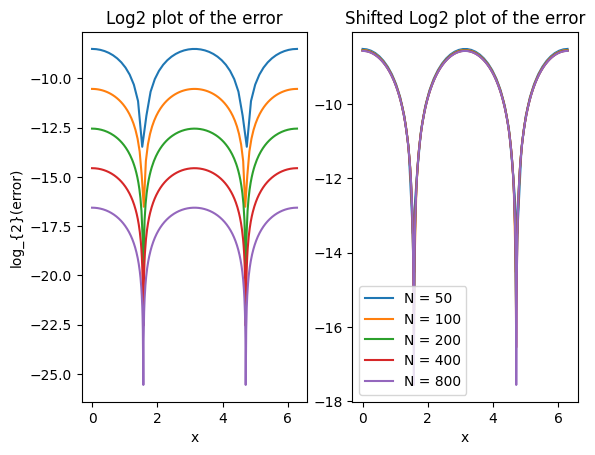

In [ ]:
num_runs = 5 # Number of tests to run

# Set grid parameters
Ngz = 2
x_min = 0.0
x_max = 2*np.pi

fig, ax = plt.subplots(1,2)
for i in range(num_runs):

  N = 50*2**(i) # Grid resolution
  dx = (x_max - x_min)/(N-1)
  grid = np.zeros(N+2*Ngz)
  for k in range(N + 2*Ngz):
    grid[k] = x_min + (k - Ngz)*dx

  # Compute finite difference and the error
  u = np.sin(grid)
  du = FD_C2(u,dx)

  error = np.abs(np.cos(grid) - du)

  # Plot log_{2}(error)
  ax[0].plot(grid[2:-2],np.log2(error[2:-2]),label="N = " +str(N))
  ax[0].set_ylabel('log_{2}(error)')
  ax[0].set_xlabel('x')
  ax[0].set_title('Log2 plot of the error')

  # Plot log_{2}(error) shifted by 2^{2*i}
  ax[1].plot(grid[2:-2],np.log2(2**(2*i)*error[2:-2]),label="N = " +str(N))
  ax[1].set_title('Shifted Log2 plot of the error')
  ax[1].set_xlabel('x')


plt.legend()
plt.show()


Observe that the errors almost perfectly align on the shifted plot above, indicating that our numerical approximation is converging at the expected second order.

This is known as a **convergence test** and verifies that the (approximate) error in our numerical scheme decreases at the expected rate.

## Solving the Advection Equation with Finite Difference Methods

Now, let's use finite differences to solve the 1+1 advection equation
$\partial_{t}u + \partial_{x}u = 0$.


We will use first-order finite differences to approximate both the time and space derivative. This is sometimes called the *upwind* method.

Our discrete scheme now takes the form:

$\frac{u^{n+1}_{i} - u^{n}_{i}}{\Delta t} + \frac{u^{n}_{i} - u^{n}_{i-1}}{\Delta x} = 0$

Re-arranging for $u^{n+1}_{i}$ yields the update formula

$u^{n+1}_{i} = u^{n}_{i} - \frac{\Delta t}{\Delta x}(u^{n}_{i} - u^{n}_{i-1})$


We will set the timestep to be a multiple of the spatial step,
$\Delta t = \lambda \Delta x$. To ensure stability of the scheme, we require $\lambda < 1$.

This is known as the Courants-Friedrichs-Lewy condition and ensures that the computational domain of dependence is *contained* in the analytic domain of dependence.


In [ ]:
################### Advection Equation  Example ###########################

# Set up computational domain
N = 100
Ngz = 2
x_min = 0.0
x_max = 2*np.pi
dx = (x_max - x_min)/(N-1)

grid = np.zeros(N) # Initialise array for the computational grid

for i in range(N):
  grid[i] = x_min + (i)*dx


# Set the initial data
u0 = np.sin(grid)
t0 = 0 # Initial time
tend = 5 # Final time

# Set the timestep
dt = 0.5*dx

# Lists for storing data
soln = []
times = []
soln.append(u0)
times.append(t0)

### Evolution loop
u_new = np.zeros_like(u0)
while (t0 < tend):

  # Handle left boundary
  u_new[0] = u0[0] - dt/dx *(u0[0] - u0[-1]) # Periodic boundary condition

  # Loop for all other interior points
  for i in range(1,N):
    u_new[i] = u0[i] - dt/dx *(u0[i] - u0[i-1])

  # Update time/solution data
  t0 += dt
  times.append(t0)
  soln.append(u_new.copy())
  u0 = u_new


# Plot solution
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
line, = ax.plot(grid, soln[0])

def animate(i):
    line.set_ydata(soln[i])
    ax.set_title(f"t = {times[i]:.3f}")
    return line,

ani = FuncAnimation(fig, animate, frames=len(times), interval=50, blit=True)

HTML(ani.to_jshtml())




This cell output is too large and can only be displayed while logged in.


# Gowdy Spacetimes

As a final example, let's consider the class of Gowdy spacetimes in vacuum.


We will implement a second-order finite difference scheme and replicate a plot from David Garfinkle's 2002 paper "Simulations of Generic Singularities
in Harmonic Coordinates".



### Method of Lines

Instead of discretising both time and space derivatives with finite difference stencils, we will use an approach called the *method of lines*.

In this case, we discretise just the spatial derivatives using finite difference stencils leaving time continuous. This yields a system of ODEs in time for each spatial gridpoint, known as a semi-discrete system.


To obtain a fully discrete system we can then use standard ODE integrators, such as Runge-Kutta methods, to evolve in time.

First, let's write a function to perform a third-order Runge-Kutta update.

In [ ]:
##################################################
# RK3 Integrator
#################################################
def rk3(t0,y0,dt,rhs,BCs,Ngz):
  """ The 3rd Order SSP RK integrator of Shu-Osher

  Inputs:
      t0 - The current time
      y0 - The current solution vector
      dt - The timestep
      rhs - A function which computes the right hand side of the PDE
      BCs - A function to update ghost points using boundary conditions
      Ngz - Number of ghost points """

  k1 = rhs(t0, y0)
  y1 = y0 + dt*k1
  y1 = BCs(y1,Ngz)

  k2 = rhs(t0 + dt, y1)
  y2 = y0 + 0.25*dt*(k1 + k2)
  y2 = BCs(y2,Ngz)

  k3 = rhs(t0 + 0.5*dt, y2)

  y0 = y0 + dt*(1/6*k1 + 1/6*k2 + 2/3*k3)
  y0 = BCs(y0,Ngz)

  return y0

Now, we need to create functions to apply the boundary conditions and evolve the system.

In [ ]:
##################################################
# Boundary Conditions
#################################################
def periodic_BC(u,Ngz):
  """ Inputs:

        u - The array to be updated
        Ngz - The number of ghost points
    """

  # Left Boundary
  u[:,:Ngz] = u[:,-2*Ngz:-Ngz]

  # Right Boundary
  u[:,-Ngz:] = u[:,Ngz:2*Ngz]

  return u

############################################
# Evolve System Routine
############################################

def evolve_system(yinit,t0,tend,dx,rk,rhs,BCs,Nghosts):

    y0 = yinit
    y_store = []
    y_store.append(yinit)
    t_store = []
    t_store.append(t0)
    i = 0

    CFL = 0.2
    dt = CFL*dx
    while t0<tend:

        i += 1

        if t0 + dt > tend:
             dt = tend-t0
             print("Simulation ending, adjusting timestep to dt = " +str(dt))

        y0 = rk(t0,y0,dt,rhs,BCs,Nghosts)
        t0 += dt

        # Store solution every x timesteps
        if i == 1:
            t_store.append(t0)
            y_store.append(y0)
            i = 0

    return t_store, y_store



Next, we need to define a function to solve the right hand side of our PDE.

Since the Gowdy equations have second spatial derivatives, we also need to define another finite difference function to compute 2nd derivatives.

In [ ]:

#### 2nd Derivative F.D. Stencil
def FD2_C2(u,dx):

  du = np.zeros_like(u)

  du[2:-2] = (u[3:-1] -2*u[2:-2] + u[1:-3])/(dx**2)

  return du

#### Gowdy evolution equations
def gowdy(t,u,dx,Ngz):

  dudt = np.zeros_like(u) # Time derivative vector

  ##### Split variables from solution vector
  P0 = u[0,:]
  Q0 = u[1,:]
  P = u[2,:]
  Q = u[3,:]


  ########### Gowdy Equations ###############
  dudt[0,Ngz:-Ngz] = np.exp(-2*t)*FD2_C2(P,dx)[Ngz:-Ngz] + np.exp(2*P[Ngz:-Ngz])\
                *(Q0[Ngz:-Ngz]**2 - np.exp(-2*t)*FD_C2(Q,dx)[Ngz:-Ngz]**2)

  dudt[1,Ngz:-Ngz] = np.exp(-2*t)*FD2_C2(Q,dx)[Ngz:-Ngz] - 2*(P0[Ngz:-Ngz]*Q0[Ngz:-Ngz] \
                - np.exp(-2*t)*FD_C2(P,dx)[Ngz:-Ngz]*FD_C2(Q,dx)[Ngz:-Ngz])

  dudt[2,Ngz:-Ngz] = P0[Ngz:-Ngz]

  dudt[3,Ngz:-Ngz] = Q0[Ngz:-Ngz]



  return dudt

All that remains is to create the computational grid, set our initial data, and run a simulation

In [ ]:
######### Create Computational Grid ###############
N = 500
Ngz = 2
x_min = 0.0
x_max = 2*np.pi
dx = (x_max - x_min)/(N-1)

grid = np.zeros(N+2*Ngz)

for i in range(N + 2*Ngz):
  grid[i] = x_min + (i - Ngz)*dx



######### Set initial data ###############

# This initial data is taken from Garfinkle "Simulations of Generic Singularities
# in Harmonic Coordinates"
P0 = 5*np.cos(grid)
Q0 = 0*grid
P = 0*grid
Q = np.cos(grid)

# Collect initial data into array
y0 = np.array([P0,Q0,P,Q])

# Apply BCs initially
y0 = periodic_BC(y0,Ngz)


######### Simulation Parameters ###############
t0 = 0
tend = np.pi

rhs = lambda t,y: gowdy(t,y,dx,Ngz) # Make anonymous function
                                    # from gowdy to fit Runge-Kutta routine


t_soln, y_soln = evolve_system(y0,t0,tend,dx,rk3,rhs,periodic_BC,Ngz)
t = np.array(t_soln)
y = np.array(y_soln)

Simulation ending, adjusting timestep to dt = 0.0012591553721317261


Now, we can plot the value of the metric function $P$ at the last time step

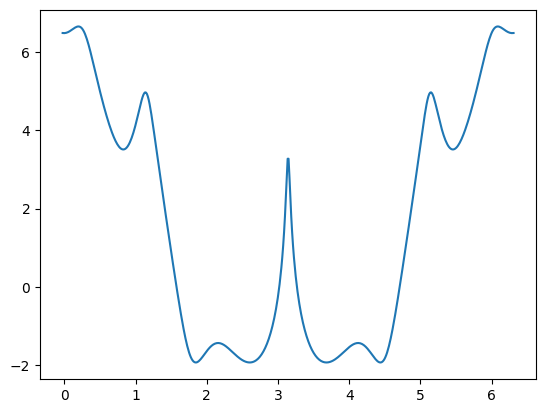

In [ ]:
# Plot solution
plt.cla()
plt.plot(grid,y[-1,2,:])
plt.show()


Our plot closely matches the plot from Garfinkle's paper: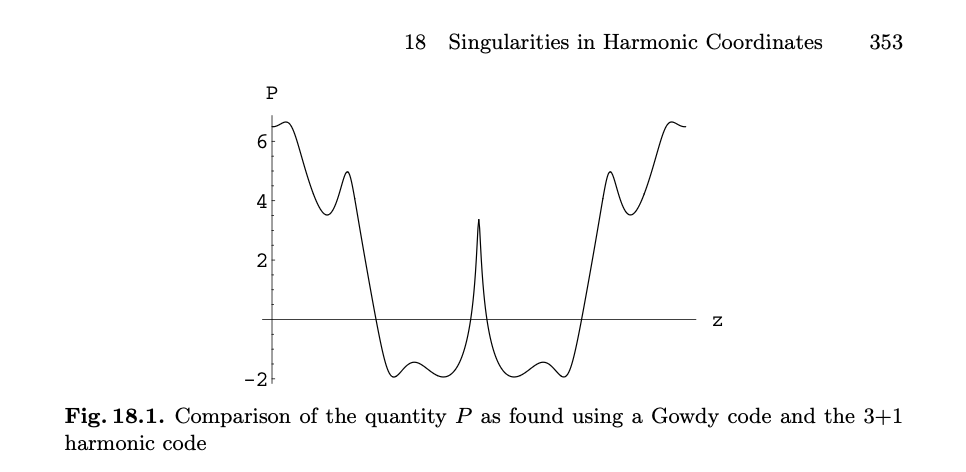